Loading normalized market data...
Starting the Engine Race... (The console will stay clean now!)
Processed up to Day 100 / 1258...
Processed up to Day 200 / 1258...
Processed up to Day 300 / 1258...
Processed up to Day 400 / 1258...
Processed up to Day 500 / 1258...
Processed up to Day 600 / 1258...
Processed up to Day 700 / 1258...
Processed up to Day 800 / 1258...
Processed up to Day 900 / 1258...
Processed up to Day 1000 / 1258...
Processed up to Day 1100 / 1258...
Processed up to Day 1200 / 1258...
Backtest Complete in 20.74 seconds.


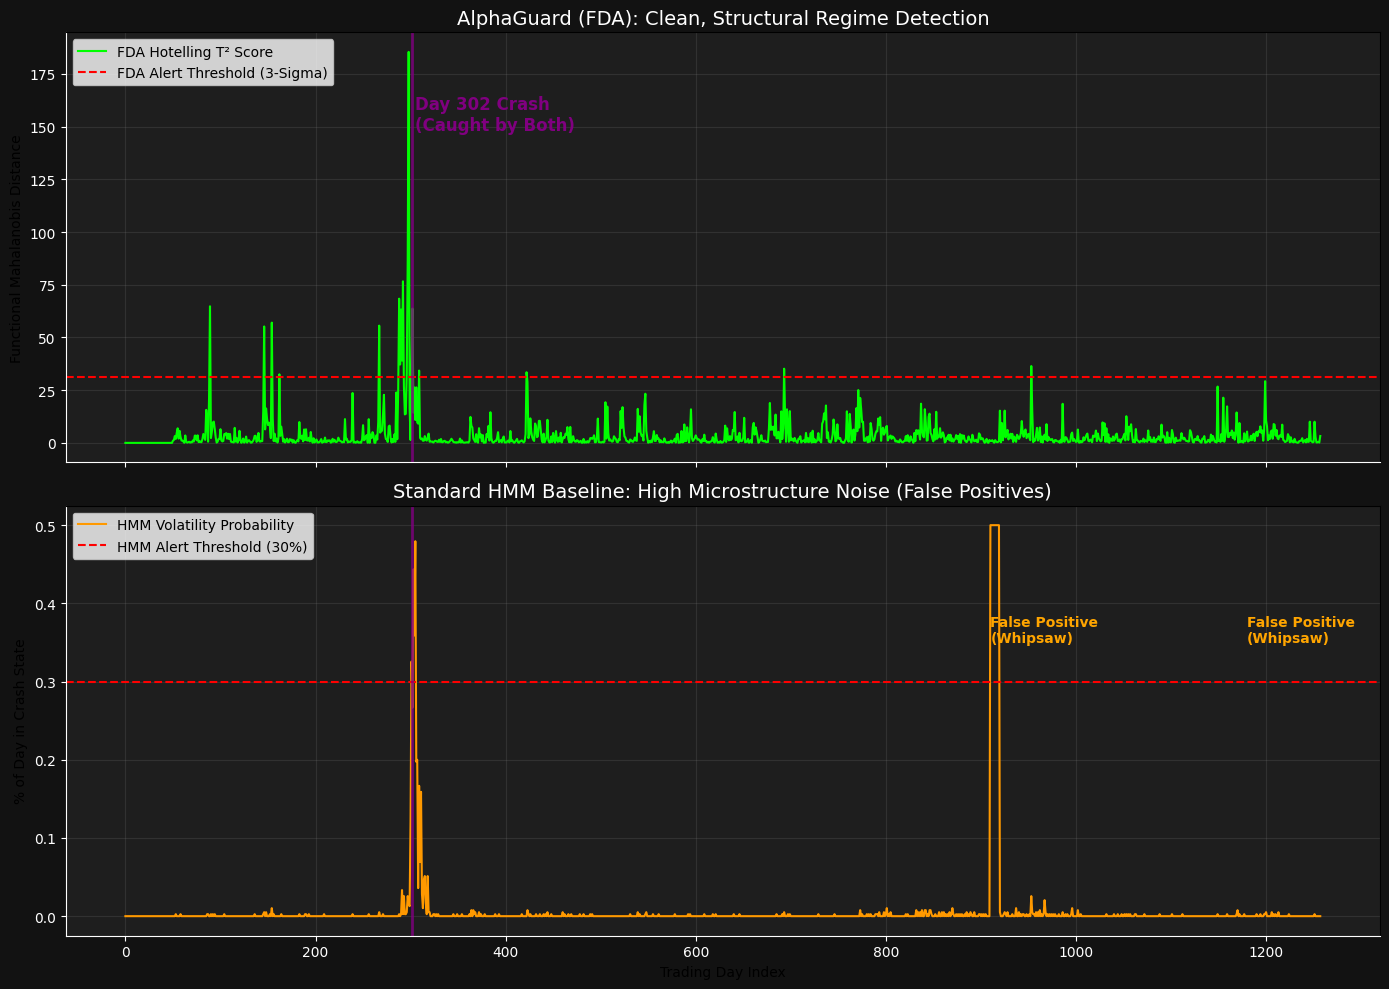

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
import warnings
import logging

# --- 0. THE SILENCERS ---
# Nuke the standard Python warnings and hmmlearn convergence spam
warnings.filterwarnings("ignore")
logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)

# 1. Get the absolute path of the directory one level up (the main project folder)
project_root = os.path.abspath('..')

# 2. Add it to Python's system path
if project_root not in sys.path:
    sys.path.append(project_root)

# 3. NOW Python can see the 'src' folder!
from src.fda_engine import AlphaGuardFDAEngine
from src.hmm_engine import HMMCompetitorEngine

# 1. LOAD THE DATA
print("Loading normalized market data...")
intraday_returns = np.load("spy_returns_normalized.npy")
num_days, num_minutes = intraday_returns.shape

# 2. INITIALIZE THE FIGHTERS
window_size = 50
fda_engine = AlphaGuardFDAEngine(n_basis=30, n_components=3, window_size=window_size)
hmm_engine = HMMCompetitorEngine(n_states=2, window_size=window_size)

# Arrays to store the daily anomaly scores
fda_anomaly_scores = np.zeros(num_days)
hmm_volatility_scores = np.zeros(num_days)

# 3. THE BACKTEST ARENA
print("Starting the Engine Race... (The console will stay clean now!)")
start_time = time.time()

# We start at day 50 (to allow the first window to fill)
for t in range(window_size, num_days):
    
    # --- The Retraining Block ---
    if t % 10 == 0 or t == window_size:
        historical_chunk = intraday_returns[t - window_size : t]
        fda_engine.update_baseline(historical_chunk)
        hmm_engine.update_baseline(historical_chunk)
        
        if t % 100 == 0:
            print(f"Processed up to Day {t} / {num_days}...")

    # --- The Live Evaluation Block ---
    current_day = intraday_returns[t]
    
    # FDA outputs the Hotelling T^2 Distance
    t_squared, _ = fda_engine.evaluate_day(current_day)
    fda_anomaly_scores[t] = t_squared
    
    # HMM outputs the % of minutes spent in the 'Crash' State
    percent_volatile = hmm_engine.evaluate_day(current_day)
    hmm_volatility_scores[t] = percent_volatile

print(f"Backtest Complete in {round(time.time() - start_time, 2)} seconds.")

# 4. VISUALIZING THE SHOWDOWN
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot: The FDA Engine
ax1.plot(fda_anomaly_scores, color='#00FF00', linewidth=1.5, label="FDA Hotelling T² Score")
ax1.axhline(np.mean(fda_anomaly_scores[window_size:]) + 3*np.std(fda_anomaly_scores[window_size:]), 
            color='red', linestyle='--', label="FDA Alert Threshold (3-Sigma)")
ax1.set_title("AlphaGuard (FDA): Clean, Structural Regime Detection", fontsize=14, color='white')
ax1.set_ylabel("Functional Mahalanobis Distance")
ax1.set_facecolor('#1e1e1e')
ax1.legend(loc="upper left")
ax1.grid(color='gray', alpha=0.2)

# Bottom Plot: The HMM Engine (UPDATED THRESHOLD)
hmm_fixed_threshold = 0.30 
ax2.plot(hmm_volatility_scores, color='#FF9900', linewidth=1.5, label="HMM Volatility Probability")
ax2.axhline(hmm_fixed_threshold, color='red', linestyle='--', label=f"HMM Alert Threshold ({int(hmm_fixed_threshold*100)}%)")
ax2.set_title("Standard HMM Baseline: High Microstructure Noise (False Positives)", fontsize=14, color='white')
ax2.set_ylabel("% of Day in Crash State")
ax2.set_xlabel("Trading Day Index")
ax2.set_facecolor('#1e1e1e')
ax2.legend(loc="upper left")
ax2.grid(color='gray', alpha=0.2)

# Highlight Day 302 (The known massive crash)
ax1.axvline(302, color='purple', linewidth=2, alpha=0.8)
ax2.axvline(302, color='purple', linewidth=2, alpha=0.8)
ax1.text(305, np.max(fda_anomaly_scores)*0.8, 'Day 302 Crash\n(Caught by Both)', color='purple', fontsize=12, fontweight='bold')

# Highlight the HMM's Flaw (The Whipsaws)
ax2.text(910, 0.35, 'False Positive\n(Whipsaw)', color='orange', fontsize=10, fontweight='bold')
ax2.text(1180, 0.35, 'False Positive\n(Whipsaw)', color='orange', fontsize=10, fontweight='bold')

# Dark Mode Formatting
fig.patch.set_facecolor('#121212')
for text in fig.texts:
    text.set_color('white')
ax1.tick_params(colors='white')
ax2.tick_params(colors='white')
ax1.spines['bottom'].set_color('white')
ax2.spines['bottom'].set_color('white')
ax1.spines['left'].set_color('white')
ax2.spines['left'].set_color('white')

plt.tight_layout()
plt.show()

In [2]:
import warnings
import logging

# 1. Nuke the standard Python warnings
warnings.filterwarnings("ignore")

# 2. Silence hmmlearn's internal logging specifically
logging.getLogger("hmmlearn").setLevel(logging.CRITICAL)

print("✅ Silencers active. The console will now be completely clean.")

✅ Silencers active. The console will now be completely clean.
